# Meta Heurística
---

In [4]:
import sys
from pathlib import Path

diretorio_atual = Path.cwd()

pasta_src = diretorio_atual / "article" / "src"

if str(pasta_src) not in sys.path:
    sys.path.append(str(pasta_src))
    
from genetic_selector import GeneticFeatureSelector
from ga_common import GAConfig, Score, GAResult

In [5]:
import os
import numpy as np
import pandas as pd
import warnings
import threading
import matplotlib.pyplot as plt
import unidecode
import re
from pathlib import Path

from dataclasses import dataclass
from joblib import Parallel, delayed

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [6]:
meta_dataset = pd.read_csv("data/metafeatures_dataset_with_best.csv")

classifier_cols = [c for c in meta_dataset.columns if c in ['DecisionTree', 'SVM', 'KNN',
                                                           'LogisticRegression', 'Perceptron', 'MLP']]
meta_feature_cols = [c for c in meta_dataset.columns if c not in ['Dataset', 'Best'] + classifier_cols]

## Pré Processamento
---

Nesta seção reunimos os passos de pré-processamento: leitura do dataset, filtragem não-supervisionada (valores ausentes, constantes, duplicadas e alta correlação), filtro supervisionado por Mutual Information e definição de `X_df`, `y`, `feature_cols` e `cv`. Execute esta célula antes de rodar qualquer AG.

In [7]:
base_config = GAConfig()

feature_cols = list(meta_feature_cols)

missing_features = [col for col in feature_cols if col not in meta_dataset.columns]

if missing_features:
    raise ValueError(f"As seguintes features não existem em meta_dataset: {missing_features}")

if base_config.target_col not in meta_dataset.columns:
    raise ValueError(f"A coluna alvo '{base_config.target_col}' não existe em meta_dataset.")

target_raw = meta_dataset[base_config.target_col].copy()

valid_target_mask = target_raw.notna()
dataset_ga = meta_dataset.loc[valid_target_mask].copy()
target_raw = dataset_ga[base_config.target_col].copy()

class_counts_before = target_raw.value_counts()

valid_classes = class_counts_before[
    class_counts_before >= base_config.min_samples_per_class
].index

rare_classes = class_counts_before[
    class_counts_before < base_config.min_samples_per_class
]

if len(rare_classes) > 0:
    print("Classes removidas por terem poucas amostras:")
    print(rare_classes)
    print("-" * 90)

dataset_ga = dataset_ga[
    dataset_ga[base_config.target_col].isin(valid_classes)
].copy()

X_df = dataset_ga[feature_cols].reset_index(drop=True)
y = dataset_ga[base_config.target_col].reset_index(drop=True)

import hashlib


@dataclass(frozen=True)
class FeatureFilterConfig:
    missing_threshold: float = 0.60
    quasi_constant_threshold: float = 0.98
    correlation_threshold: float = 0.985
    use_correlation_filter: bool = True


filter_config = FeatureFilterConfig(
    missing_threshold=0.60,
    quasi_constant_threshold=0.98,
    correlation_threshold=0.985,
    use_correlation_filter=True
)


def column_fingerprint(series):
    values = series.astype("string").fillna("__missing__")
    hashes = pd.util.hash_pandas_object(values, index=False).to_numpy(dtype=np.uint64)
    return hashlib.blake2b(hashes.tobytes(), digest_size=16).hexdigest()


def filter_features_unsupervised(X_df, config):
    X = X_df.copy()
    report = []

    initial_features = X.shape[1]

    missing_ratio = X.isna().mean()
    cols_high_missing = missing_ratio[missing_ratio > config.missing_threshold].index.tolist()
    X = X.drop(columns=cols_high_missing)

    report.append({
        "etapa": "Muitos valores ausentes",
        "removidas": len(cols_high_missing),
        "restantes": X.shape[1]
    })

    nunique = X.nunique(dropna=True)
    cols_constant = nunique[nunique <= 1].index.tolist()
    X = X.drop(columns=cols_constant)

    report.append({
        "etapa": "Constantes",
        "removidas": len(cols_constant),
        "restantes": X.shape[1]
    })

    cols_quasi_constant = []

    for col in X.columns:
        freq = X[col].value_counts(dropna=False, normalize=True)

        if len(freq) > 0 and freq.iloc[0] >= config.quasi_constant_threshold:
            cols_quasi_constant.append(col)

    X = X.drop(columns=cols_quasi_constant)

    report.append({
        "etapa": "Quase constantes",
        "removidas": len(cols_quasi_constant),
        "restantes": X.shape[1]
    })

    seen = {}
    cols_duplicate = []

    for col in X.columns:
        fp = column_fingerprint(X[col])

        if fp in seen:
            base_col = seen[fp]

            s1 = X[col].astype("string").fillna("__missing__")
            s2 = X[base_col].astype("string").fillna("__missing__")

            if s1.equals(s2):
                cols_duplicate.append(col)
        else:
            seen[fp] = col

    X = X.drop(columns=cols_duplicate)

    report.append({
        "etapa": "Duplicadas",
        "removidas": len(cols_duplicate),
        "restantes": X.shape[1]
    })

    cols_correlated = []

    if config.use_correlation_filter:
        numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

        if len(numeric_cols) > 1:
            X_num = X[numeric_cols].copy()
            X_num = X_num.apply(pd.to_numeric, errors="coerce")
            X_num = X_num.fillna(X_num.median(numeric_only=True))
            X_num = X_num.fillna(0)

            corr = X_num.corr().abs()
            upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

            cols_correlated = [
                col for col in upper.columns
                if any(upper[col] > config.correlation_threshold)
            ]

            X = X.drop(columns=cols_correlated)

    report.append({
        "etapa": "Alta correlação numérica",
        "removidas": len(cols_correlated),
        "restantes": X.shape[1]
    })

    report_df = pd.DataFrame(report)

    removed_features = list(set(X_df.columns) - set(X.columns))

    summary = {
        "features_iniciais": initial_features,
        "features_finais": X.shape[1],
        "features_removidas": len(removed_features),
        "removed_features": removed_features,
        "report": report_df
    }

    return X, summary


X_df, filter_summary = filter_features_unsupervised(
    X_df=X_df,
    config=filter_config
)

feature_cols = list(X_df.columns)
n_total_features = len(feature_cols)

print("Resumo da filtragem inicial:")
print(filter_summary["report"])
print("-" * 90)
print(f"Features antes: {filter_summary['features_iniciais']}")
print(f"Features depois: {filter_summary['features_finais']}")
print(f"Features removidas: {filter_summary['features_removidas']}")

class_counts = y.value_counts()

if y.nunique() < 2:
    raise ValueError(
        "Após remover classes raras, sobrou apenas uma classe em 'Best'. "
        "Não é possível treinar um classificador supervisionado."
    )

min_class_count = int(class_counts.min())
cv_splits = min(base_config.cv_splits, min_class_count)

if cv_splits < 2:
    raise ValueError(
        "Não há amostras suficientes para validação cruzada. "
        "Você precisa de pelo menos 2 amostras por classe."
    )

n_total_features = len(feature_cols)

cv = StratifiedKFold(
    n_splits=cv_splits,
    shuffle=True,
    random_state=base_config.random_state
)

print("Distribuição original das classes:")
print(class_counts_before)

print("\nDistribuição usada no AG:")
print(class_counts)

print(f"\nCV ajustado para {cv_splits} folds.")
print(f"Features totais: {n_total_features}")
print(f"Amostras usadas: {len(X_df)}")
print("-" * 90)

Classes removidas por terem poucas amostras:
Best
Perceptron    1
Name: count, dtype: int64
------------------------------------------------------------------------------------------
Resumo da filtragem inicial:
                      etapa  removidas  restantes
0   Muitos valores ausentes        120       1027
1                Constantes         32        995
2          Quase constantes          8        987
3                Duplicadas          6        981
4  Alta correlação numérica         88        893
------------------------------------------------------------------------------------------
Features antes: 1147
Features depois: 893
Features removidas: 254
Distribuição original das classes:
Best
LogisticRegression    36
DecisionTree          22
SVM                   17
MLP                   10
KNN                    8
Perceptron             1
Name: count, dtype: int64

Distribuição usada no AG:
Best
LogisticRegression    36
DecisionTree          22
SVM                   17
MLP     

In [8]:
base_estimator = ExtraTreesClassifier(
    n_estimators=180,
    max_features="sqrt",
    class_weight="balanced",
    random_state=base_config.random_state,
    n_jobs=1
)


def build_pipeline():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, make_column_selector(dtype_include=np.number)),
            ("cat", categorical_pipeline, make_column_selector(dtype_exclude=np.number))
        ],
        remainder="drop"
    )

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", clone(base_estimator))
    ])

In [9]:
def compute_feature_ranking(X_df, y, feature_cols, random_state=42):
    rng = np.random.default_rng(random_state)
    scores = np.zeros(len(feature_cols), dtype=float)

    for i, col in enumerate(feature_cols):
        s = X_df[col]

        try:
            if pd.api.types.is_numeric_dtype(s):
                s_num = pd.to_numeric(s, errors="coerce")
                median_value = s_num.median()

                if pd.isna(median_value):
                    median_value = 0.0

                arr = s_num.fillna(median_value).to_numpy().reshape(-1, 1)
                discrete = False
            else:
                arr = (
                    s.astype("string")
                    .fillna("__missing__")
                    .astype("category")
                    .cat.codes
                    .to_numpy()
                    .reshape(-1, 1)
                )
                discrete = True

            score = mutual_info_classif(
                arr,
                y,
                discrete_features=discrete,
                random_state=random_state
            )[0]

            scores[i] = 0.0 if np.isnan(score) else score

        except Exception:
            scores[i] = 0.0

    ranking = np.argsort(scores)[::-1]

    if np.all(scores == 0):
        ranking = rng.permutation(len(feature_cols))

    ranking_df = pd.DataFrame({
        "feature": feature_cols,
        "filter_score": scores
    }).sort_values("filter_score", ascending=False)

    return ranking, scores, ranking_df


feature_ranking, feature_filter_scores, feature_ranking_df = compute_feature_ranking(
    X_df=X_df,
    y=y,
    feature_cols=feature_cols,
    random_state=base_config.random_state
)

feature_ranking_df.head(20)

,feature,filter_score
521,min.histogram.9,0.327880
511,median.histogram.9,0.327474
275,h_mean.histogram.9,0.324878
385,leaves,0.290867
823,var.histogram.0,0.278510
73,class_conc.histogram.0,0.266457
52,best_node.max,0.263372
306,iq_range.histogram.0,0.259687
469,mad.histogram.0,0.254818
184,elite_nn.median.relative,0.247767


In [10]:
use_supervised_prefilter = True

supervised_top_k = min(150, n_total_features)

if use_supervised_prefilter:
    selected_prefilter_features = (
        feature_ranking_df
        .head(supervised_top_k)["feature"]
        .tolist()
    )

    X_df = X_df[selected_prefilter_features].copy()
    feature_cols = list(X_df.columns)
    n_total_features = len(feature_cols)

    feature_ranking, feature_filter_scores, feature_ranking_df = compute_feature_ranking(
        X_df=X_df,
        y=y,
        feature_cols=feature_cols,
        random_state=base_config.random_state
    )

    print(f"Filtro supervisionado aplicado.")
    print(f"Top-k usado: {supervised_top_k}")
    print(f"Features restantes: {n_total_features}")
else:
    print("Filtro supervisionado não aplicado.")

Filtro supervisionado aplicado.
Top-k usado: 150
Features restantes: 150


## Abordagens dos Algoritmos Genéticos
---
Este notebook contém três variações do Algoritmo Genético (AG) usadas para seleção de meta-features. A ideia é comparar estratégias de inicialização, operadores genéticos e o uso (ou não) de busca local:
- **AG 1 - Clássico binário**: AG tradicional com inicialização aleatória, crossover de um ponto e mutação por flip. Focado em explorar o espaço com penalidade de parsimonia leve.
- **AG 2 - Guiado por MI + busca local**: Inicialização guiada pelo ranking de Mutual Information (MI), crossover uniforme e busca local (hill-climbing) aplicada para refinar soluções. Usa penalidade maior e estabilidade considerada.
- **AG 3 - Compacto/esparso**: Objetivo de obter subconjuntos pequenos. Inicialização guiada, mutação adaptativa esparsa e restrição por `hard_max_features` para produzir soluções compactas. Mais forte penalidade de parsimonia.

Abaixo fazemos a definição prática dessas três configurações (cada uma com uma breve explicação antes do código).

In [11]:
# Calcula um limite razoável para a configuração compacta
hard_max_features_compact = max(
    1,
    min(
        n_total_features,
        max(5, n_total_features // 8)
    )
)

### AG 1 - Clássico binário
---

Descrição: AG tradicional que representa soluções como vetores binários. A inicialização é aleatória (probabilidades entre `init_min_prob` e `init_max_prob`), o crossover padrão é de um ponto e a mutação inverte bits (`flip`). Não utiliza busca local, priorizando exploração do espaço. A penalidade de parsimonia é moderada para evitar conjuntos muito grandes.

In [12]:
ga_cfg_ag1 = GAConfig(
    name="AG 1 - Clássico binário",
    target_col=base_config.target_col,
    population_size=80,
    generations=150,
    elitism=4,
    tournament_size=4,
    crossover_rate=0.85,
    mutation_start=0.10,
    mutation_end=0.02,
    init_min_prob=0.08,
    init_max_prob=0.40,
    parsimony_weight=0.04,
    parsimony_power=1.10,
    stability_weight=0.05,
    cv_splits=cv_splits,
    scoring="accuracy",
    patience=25,
    immigrant_rate=0.08,
    hard_max_features=None,
    initialization_strategy="random",
    crossover_mode="one_point",
    mutation_mode="flip",
    use_local_search=False,
    n_jobs=-1,
    random_state=42,
)


In [13]:
# Executar AG 1 - Clássico binário
results = []
print("Executando: AG 1 - Clássico binário")
selector = GeneticFeatureSelector(
    X_df=X_df,
    y=y,
    feature_cols=feature_cols,
    feature_ranking=feature_ranking,
    pipeline_factory=build_pipeline,
    cv=cv,
    config=ga_cfg_ag1
)
result_ag1 = selector.fit(verbose=True)
final_model = build_pipeline()
final_model.fit(X_df[result_ag1.selected_features], y)
result_ag1.model = final_model
results.append(result_ag1)
print("AG 1 concluído.")

Executando: AG 1 - Clássico binário
AG 1 - Clássico binário
População: 80
Gerações máximas: 150
Scoring: accuracy
Inicialização: random
Crossover: one_point
Mutação: flip
Busca local: False
------------------------------------------------------------------------------------------
Geração 000 | Acurácia: 0.56842 ± 0.08331 | Features: 18/150 | Fitness: 0.56037 | Sem melhora: 0/25
Geração 001 | Acurácia: 0.58012 ± 0.10365 | Features: 59/150 | Fitness: 0.56060 | Sem melhora: 0/25


KeyboardInterrupt: 

### AG 2 - Guiado por MI + busca local
---

Descrição: Inicialização guiada usando o ranking por Mutual Information (MI) — isto significa que sementes com as `k` melhores features são incluídas na população inicial. Usa crossover uniforme e uma estratégia de mutação (`remove_bias`) que tende a remover atributos menos promissores. Além disso aplica busca local (variações por remoção/adição) para refinar soluções promissoras. Essa combinação costuma convergir mais rápido e produzir soluções estáveis.

In [ ]:
ga_cfg_ag2 = GAConfig(
    name="AG 2 - Guiado por MI + busca local",
    target_col=base_config.target_col,
    population_size=80,
    generations=150,
    elitism=4,
    tournament_size=4,
    crossover_rate=0.85,
    mutation_start=0.08,
    mutation_end=0.015,
    init_min_prob=0.05,
    init_max_prob=0.30,
    parsimony_weight=0.08,
    parsimony_power=1.25,
    stability_weight=0.10,
    cv_splits=cv_splits,
    scoring="accuracy",
    patience=25,
    immigrant_rate=0.12,
    local_search_rounds=4,
    local_search_add_candidates=25,
    hard_max_features=None,
    initialization_strategy="guided",
    crossover_mode="uniform",
    mutation_mode="remove_bias",
    use_local_search=True,
    n_jobs=-1,
    random_state=42,
)


In [ ]:
# Executar AG 2 - Guiado por MI + busca local
print("Executando: AG 2 - Guiado por MI + busca local")
selector = GeneticFeatureSelector(
    X_df=X_df,
    y=y,
    feature_cols=feature_cols,
    feature_ranking=feature_ranking,
    pipeline_factory=build_pipeline,
    cv=cv,
    config=ga_cfg_ag2
)
result_ag2 = selector.fit(verbose=True)
final_model = build_pipeline()
final_model.fit(X_df[result_ag2.selected_features], y)
result_ag2.model = final_model
results.append(result_ag2)
print("AG 2 concluído.")

Executando: AG 2 - Guiado por MI + busca local
AG 2 - Guiado por MI + busca local
População: 80
Gerações máximas: 150
Scoring: accuracy
Inicialização: guided
Crossover: uniform
Mutação: remove_bias
Busca local: True
------------------------------------------------------------------------------------------
Geração 000 | Acurácia: 0.60175 ± 0.04486 | Features: 34/150 | Fitness: 0.58476 | Sem melhora: 0/25
Geração 001 | Acurácia: 0.61170 ± 0.13184 | Features: 15/150 | Fitness: 0.59401 | Sem melhora: 0/25
Geração 002 | Acurácia: 0.61170 ± 0.13184 | Features: 15/150 | Fitness: 0.59401 | Sem melhora: 1/25
Geração 003 | Acurácia: 0.61170 ± 0.13184 | Features: 15/150 | Fitness: 0.59401 | Sem melhora: 2/25
Geração 004 | Acurácia: 0.62281 ± 0.08001 | Features: 21/150 | Fitness: 0.60795 | Sem melhora: 0/25
Geração 005 | Acurácia: 0.62281 ± 0.08001 | Features: 21/150 | Fitness: 0.60795 | Sem melhora: 1/25
Geração 006 | Acurácia: 0.63392 ± 0.02676 | Features: 37/150 | Fitness: 0.61734 | Sem melhora

### AG 3 - Compacto / Esparso
---

Descrição: Voltado a encontrar subconjuntos pequenos e interpretáveis. Aplica inicialização guiada, mutação adaptativa esparsa (`sparse_adaptive`) que tende a remover características quando o conjunto é maior que o alvo esparso, e impõe `hard_max_features` para limitar o tamanho. A penalidade de parsimonia é mais forte para favorecer soluções compactas.

In [ ]:
ga_cfg_ag3 = GAConfig(
    name="AG 3 - Compacto/esparso",
    target_col=base_config.target_col,
    population_size=80,
    generations=150,
    elitism=5,
    tournament_size=5,
    crossover_rate=0.90,
    mutation_start=0.10,
    mutation_end=0.01,
    init_min_prob=0.03,
    init_max_prob=0.18,
    parsimony_weight=0.16,
    parsimony_power=1.50,
    stability_weight=0.12,
    cv_splits=cv_splits,
    scoring="accuracy",
    patience=25,
    immigrant_rate=0.15,
    local_search_rounds=5,
    local_search_add_candidates=30,
    hard_max_features=hard_max_features_compact,
    initialization_strategy="guided",
    crossover_mode="uniform",
    mutation_mode="sparse_adaptive",
    use_local_search=True,
    sparse_target_ratio=0.10,
    n_jobs=-1,
    random_state=42,
)


In [ ]:
# Agrupa as configurações para execução sequencial e comparativa
ga_configs = [ga_cfg_ag1, ga_cfg_ag2, ga_cfg_ag3]

In [ ]:
# Executar AG 3 - Compacto / Esparso
print("Executando: AG 3 - Compacto/esparso")
selector = GeneticFeatureSelector(
    X_df=X_df,
    y=y,
    feature_cols=feature_cols,
    feature_ranking=feature_ranking,
    pipeline_factory=build_pipeline,
    cv=cv,
    config=ga_cfg_ag3
)
result_ag3 = selector.fit(verbose=True)
final_model = build_pipeline()
final_model.fit(X_df[result_ag3.selected_features], y)
result_ag3.model = final_model
results.append(result_ag3)
print("AG 3 concluído.")

Executando: AG 3 - Compacto/esparso
AG 3 - Compacto/esparso
População: 80
Gerações máximas: 150
Scoring: accuracy
Inicialização: guided
Crossover: uniform
Mutação: sparse_adaptive
Busca local: True
------------------------------------------------------------------------------------------
Geração 000 | Acurácia: 0.60175 ± 0.05586 | Features: 18/150 | Fitness: 0.58840 | Sem melhora: 0/25
Geração 001 | Acurácia: 0.60175 ± 0.05586 | Features: 18/150 | Fitness: 0.58840 | Sem melhora: 1/25
Geração 002 | Acurácia: 0.61287 ± 0.03846 | Features: 16/150 | Fitness: 0.60268 | Sem melhora: 0/25
Geração 003 | Acurácia: 0.61287 ± 0.03846 | Features: 16/150 | Fitness: 0.60268 | Sem melhora: 1/25
Geração 004 | Acurácia: 0.61287 ± 0.03846 | Features: 16/150 | Fitness: 0.60268 | Sem melhora: 2/25
Geração 005 | Acurácia: 0.61287 ± 0.03846 | Features: 16/150 | Fitness: 0.60268 | Sem melhora: 3/25
Geração 006 | Acurácia: 0.62339 ± 0.07594 | Features: 18/150 | Fitness: 0.60763 | Sem melhora: 0/25
Geração 007

c:\Users\Victo\Desktop\Ufal\2026.1\cc-meta-aprendizagem-2026.1\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


Geração 016 | Acurácia: 0.65439 ± 0.06359 | Features: 18/150 | Fitness: 0.64010 | Sem melhora: 6/25
Geração 017 | Acurácia: 0.65439 ± 0.06359 | Features: 18/150 | Fitness: 0.64010 | Sem melhora: 7/25
Geração 018 | Acurácia: 0.65439 ± 0.06359 | Features: 18/150 | Fitness: 0.64010 | Sem melhora: 8/25
Geração 019 | Acurácia: 0.65439 ± 0.06359 | Features: 18/150 | Fitness: 0.64010 | Sem melhora: 9/25
Geração 020 | Acurácia: 0.66608 ± 0.09251 | Features: 18/150 | Fitness: 0.64833 | Sem melhora: 0/25
Geração 021 | Acurácia: 0.66608 ± 0.09251 | Features: 18/150 | Fitness: 0.64833 | Sem melhora: 1/25
Geração 022 | Acurácia: 0.66608 ± 0.09251 | Features: 18/150 | Fitness: 0.64833 | Sem melhora: 2/25
Geração 023 | Acurácia: 0.66608 ± 0.09251 | Features: 18/150 | Fitness: 0.64833 | Sem melhora: 3/25
Geração 024 | Acurácia: 0.66608 ± 0.09251 | Features: 18/150 | Fitness: 0.64833 | Sem melhora: 4/25
Geração 025 | Acurácia: 0.66608 ± 0.09251 | Features: 18/150 | Fitness: 0.64833 | Sem melhora: 5/25


## Resultados consolidados
Após executar cada AG individualmente, esta célula agrega os resultados em `comparison_df` para análise e exportação.

In [ ]:
comparison_df = pd.DataFrame([
    {
        "metodo": result.name,
        "accuracy_mean": result.accuracy_mean,
        "accuracy_std": result.accuracy_std,
        "fitness": result.fitness,
        "n_features": result.n_features,
        "percentual_features": result.n_features / n_total_features,
        "features": result.selected_features
    }
    for result in results
]).sort_values(
    by=["accuracy_mean", "fitness", "n_features"],
    ascending=[False, False, True]
).reset_index(drop=True)

comparison_df

,metodo,accuracy_mean,accuracy_std,fitness,n_features,percentual_features,features
0,AG 2 - Guiado por MI + busca local,0.698246,0.032158,0.678735,42,0.28,"[median.histogram.9, h_mean.histogram.9, leave..."
1,AG 3 - Compacto/esparso,0.677193,0.068063,0.662374,18,0.12,"[h_mean.histogram.9, var.histogram.0, class_co..."
2,AG 1 - Clássico binário,0.644444,0.088081,0.623015,69,0.46,"[min.histogram.9, h_mean.histogram.9, var.hist..."


In [ ]:
best_result = max(
    results,
    key=lambda result: (
        result.accuracy_mean,
        result.fitness,
        -result.n_features
    ),
)

result_ga = {
    "selected_features": best_result.selected_features,
    "selected_mask": best_result.selected_mask,
    "fitness": best_result.fitness,
    "accuracy_mean": best_result.accuracy_mean,
    "accuracy_std": best_result.accuracy_std,
    "n_features": best_result.n_features,
    "history": best_result.history,
    "model": best_result.model,
    "feature_filter_scores": feature_ranking_df,
    "class_counts_original": class_counts_before,
    "class_counts_used": class_counts,
    "comparison": comparison_df,
    "all_results": results
}

print("Melhor resultado por Acurácia:")
print(best_result.name)
print("-" * 90)
print(f"Acurácia estimada: {best_result.accuracy_mean:.5f} ± {best_result.accuracy_std:.5f}")
print(f"Fitness: {best_result.fitness:.5f}")
print(f"Features selecionadas: {best_result.n_features}/{n_total_features}")
print("-" * 90)
print(best_result.selected_features)

Melhor resultado por Acurácia:
AG 2 - Guiado por MI + busca local
------------------------------------------------------------------------------------------
Acurácia estimada: 0.69825 ± 0.03216
Fitness: 0.67874
Features selecionadas: 42/150
------------------------------------------------------------------------------------------
['median.histogram.9', 'h_mean.histogram.9', 'leaves', 'var.histogram.0', 'class_conc.histogram.0', 'wg_dist.max', 'tree_depth.histogram.5', 'range.histogram.0', 'leaves_homo.histogram.0', 'range.min', 'g_mean.histogram.9', 'random_node.histogram.8.relative', 'mad.histogram.9', 'one_nn.max.relative', 'one_nn.min', 'cov.histogram.0', 'var_importance.mean', 'min.max', 'nodes_per_level.median', 'leaves_homo.median', 'nodes_per_level.max', 'impconceptvar.histogram.2', 'mean.histogram.0', 'elite_nn.max.relative', 'random_node.mean.relative', 'elite_nn.min', 'attr_ent.histogram.0', 'naive_bayes.mean.relative', 'n3.histogram.0', 'tree_shape.min', 'naive_bayes.histogr

In [ ]:
for result in results:
    print("=" * 90)
    print(result.name)
    print(f"Acurácia: {result.accuracy_mean:.5f} ± {result.accuracy_std:.5f}")
    print(f"Fitness: {result.fitness:.5f}")
    print(f"Features: {result.n_features}/{n_total_features}")
    print("-" * 90)

    for feature in result.selected_features:
        print(feature)

AG 1 - Clássico binário
Acurácia: 0.64444 ± 0.08808
Fitness: 0.62302
Features: 69/150
------------------------------------------------------------------------------------------
min.histogram.9
h_mean.histogram.9
var.histogram.0
best_node.max
mad.histogram.0
t_mean.histogram.9
sparsity.histogram.9
leaves_corrob.mean
worst_node.mean.relative
range.histogram.0
best_node.histogram.6
range.min
g_mean.histogram.9
random_node.histogram.8.relative
nr_attr
one_nn.max.relative
leaves_homo.sd
eigenvalues.histogram.9
one_nn.min
t4
f3.mean
leaves_homo.max
cov.histogram.0
leaves_branch.mean
eigenvalues.histogram.0
one_nn.histogram.0.relative
impconceptvar.mean
tree_shape.median
elite_nn.max
nodes_per_level.median
iq_range.histogram.9
leaves_homo.median
nodes_per_level.max
one_nn.max
conceptvar.mean
tree_shape.mean
elite_nn.histogram.9.relative
mean.histogram.0
elite_nn.max.relative
random_node.mean.relative
elite_nn.min
naive_bayes.mean.relative
elite_nn.mean.relative
one_nn.mean.relative
f3.max
ran

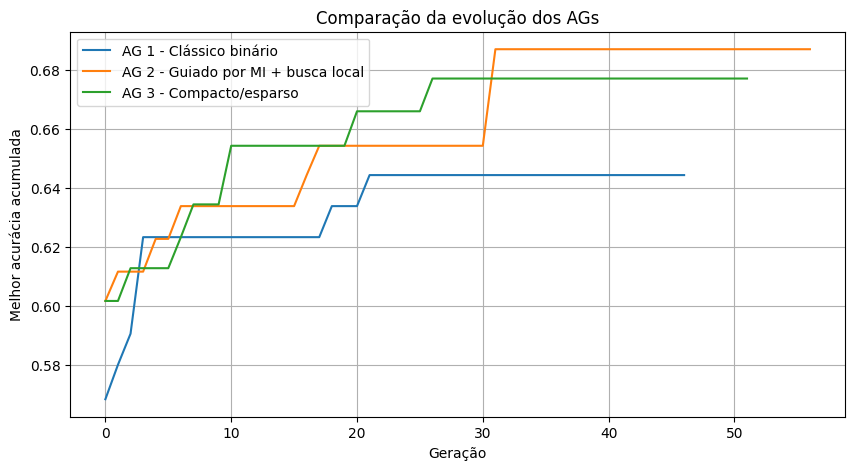

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for result in results:
    ax.plot(
        result.history["generation"],
        result.history["accuracy_mean"],
        label=result.name
    )

ax.set_xlabel("Geração")
ax.set_ylabel("Melhor acurácia acumulada")
ax.set_title("Comparação da evolução dos AGs")
ax.legend()
ax.grid(True)

os.makedirs('results/plots', exist_ok=True)
safe_name = 'evolution_ag_accuracy'
out_path = f'results/plots/{safe_name}.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

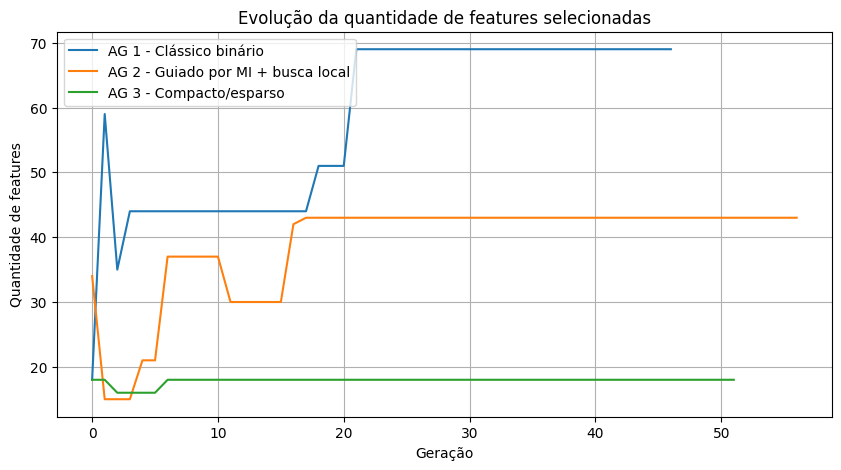

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for result in results:
    ax.plot(
        result.history["generation"],
        result.history["n_features"],
        label=result.name
    )

ax.set_xlabel("Geração")
ax.set_ylabel("Quantidade de features")
ax.set_title("Evolução da quantidade de features selecionadas")
ax.legend()
ax.grid(True)

os.makedirs('results/plots', exist_ok=True)
safe_name = 'evolution_ag_n_features'
out_path = f'results/plots/{safe_name}.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

In [ ]:
from pathlib import Path

results_path = Path("results/abordagens_meta_heuristica/")
results_path.mkdir(parents=True, exist_ok=True)

comparison_df.to_csv(f"{str(results_path)}/comparacao_algoritmos_geneticos_features.csv", index=False)
feature_ranking_df.to_csv(f"{str(results_path)}/ranking_filtro_mutual_info.csv", index=False)

print("Arquivos exportados:")
print("comparacao_algoritmos_geneticos_features.csv")
print("ranking_filtro_mutual_info.csv")

Arquivos exportados:
comparacao_algoritmos_geneticos_features.csv
ranking_filtro_mutual_info.csv


In [ ]:
# Pasta de destino
out_path = Path("results/abordagens_meta_heuristica/")
out_path.mkdir(parents=True, exist_ok=True)

for result in results:
    # Gerar nome seguro baseado no nome da abordagem
    name_clean = unidecode.unidecode(result.name).lower()
    name_clean = re.sub(r'[^a-z0-9]+', '_', name_clean).strip('_')
    csv_filename = f"metafeatures_selected_with_{name_clean}.csv"
    
    # Pegar o preprocessor do pipeline ajustado
    preprocessor = result.model.named_steps['preprocessor']
    
    # Subconjunto das features selecionadas
    X_sub = X_df[result.selected_features]
    
    # Aplicar o pré-processamento (imputação e codificação)
    X_trans = preprocessor.transform(X_sub)
    
    # Tentar recuperar os nomes das colunas após transformação
    try:
        col_names = preprocessor.get_feature_names_out()
        # Limpar os prefixos num__ e cat__ inseridos pelo ColumnTransformer
        col_names = [c.replace('num__', '').replace('cat__', '') for c in col_names]
    except AttributeError:
        col_names = [f"f_{i}" for i in range(X_trans.shape[1])]
    
    # Montar DataFrame
    import scipy.sparse
    if scipy.sparse.issparse(X_trans):
        df_saved = pd.DataFrame(X_trans.toarray(), columns=col_names)
    else:
        df_saved = pd.DataFrame(X_trans, columns=col_names)
    
    # Inserir Dataset e Best (target) do dataset_ga
    df_saved.insert(0, 'Dataset', dataset_ga['Dataset'].values)
    df_saved['Best'] = y.values
    
    # Salvar
    full_path = out_path / csv_filename
    df_saved.to_csv(full_path, index=False)
    print(f"Salvo: {full_path} com {df_saved.shape[1]-2} meta-features pré-processadas.")
